In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from features import construir_features, crear_target
from database import cargar_velas
import pandas_ta as ta
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURACIÓN
# ============================================================
PAR            = "ETHUSDT"
CAPITAL_INICIAL = 100.0
COMISION       = 0.001
STOP_LOSS      = 0.025
TAKE_PROFIT    = 0.010
UMBRAL_PROB    = 0.63
MAX_VELAS      = 96

FEATURES = [
    'close_vs_ema200', 'ema50_vs_ema200',
    'atr_relativo', 'atr_tendencia', 'bb_ancho',
    'rsi',
    'adx',
    'hora', 'dia_semana',
    'tendencia_1h', 'rsi_1h', 'adx_1h'
]

ModuleNotFoundError: No module named 'backtesting'

In [ ]:
# ============================================================
# SIMULACIÓN ESTRATEGIA CLÁSICA (sin ML)
# ============================================================
def simular_clasico(df: pd.DataFrame) -> tuple:
    """
    Estrategia original: RSI + SAR + ADX + EMA200
    Sin ningún filtro de ML.
    """
    capital     = CAPITAL_INICIAL
    posicion    = 0.0
    price_compra = 0.0
    stop_price  = 0.0
    stop_take   = 0.0
    price_tp    = 0.0
    rsi_min     = 100.0
    rsi_max     = 0.0
    en_pos      = False
    ops         = []
    equity      = []

    for i in range(1, len(df)):
        f   = df.iloc[i]
        fa  = df.iloc[i - 1]
        rsi = float(fa['RSI'])
        sar = float(fa['SAR'])
        close = float(fa['Close'])
        mm  = float(fa['MM'])
        adx = float(fa['ADX'])
        precio = float(f['Open'])

        equity.append({'time': f.name,
                        'equity': capital + posicion * precio})

        # Stop loss / take profit
        if en_pos:
            if (stop_price > 0 and close < stop_price) or \
               (stop_take > 0 and close < stop_take):
                motivo = "SL" if close < stop_price else "TP"
                ingreso = posicion * precio * (1 - COMISION)
                ops.append({'tipo': motivo,
                            'ganancia_pct': (precio/price_compra-1)*100,
                            'time': f.name, 'precio': precio})
                capital += ingreso
                posicion = en_pos = False
                stop_price = stop_take = 0.0
                rsi_min = 100.0
                rsi_max = 0.0
                continue

        # Trailing stop
        if en_pos and close > price_tp:
            price_tp = close
            stop_take = round(close * (0.995 if close < price_compra*1.02
                                       else 0.990), 6)

        # Compra
        cond = ((sar * 0.985 >= close) or (rsi <= 35)) and \
               (close > mm) and (adx > 20)
        if cond and not en_pos:
            if rsi <= rsi_min:
                rsi_min = rsi
            else:
                if capital > 11:
                    qty = capital * 0.25 / precio if capital * 0.25 > 11 \
                          else capital * 0.999 / precio
                    costo = qty * precio * (1 + COMISION)
                    if costo <= capital:
                        capital -= costo
                        posicion = qty
                        price_compra = precio
                        price_tp = round(precio * (1 + TAKE_PROFIT), 6)
                        stop_price = round(precio * (1 - STOP_LOSS), 6)
                        en_pos = True
                        rsi_min = 100.0
                        rsi_max = 0.0
                        ops.append({'tipo': 'COMPRA',
                                    'ganancia_pct': None,
                                    'time': f.name,
                                    'precio': precio})

        # Venta
        if rsi >= 72 and en_pos:
            if rsi >= rsi_max:
                rsi_max = rsi
            else:
                ingreso = posicion * precio * (1 - COMISION)
                ops.append({'tipo': 'VENTA',
                            'ganancia_pct': (precio/price_compra-1)*100,
                            'time': f.name, 'precio': precio})
                capital += ingreso
                posicion = en_pos = False
                rsi_min = 100.0
                rsi_max = 0.0

    cap_final = capital + posicion * float(df.iloc[-1]['Close'])
    return pd.DataFrame(ops), pd.DataFrame(equity), cap_final

In [ ]:
# ============================================================
# SIMULACIÓN ESTRATEGIA ML
# ============================================================
def simular_ml(features_df: pd.DataFrame,
               df_15m: pd.DataFrame,
               modelo,
               scaler) -> tuple:
    """
    Estrategia ML: el modelo decide cuándo comprar.
    Sin indicadores técnicos como filtro de entrada.
    Solo gestión de stop loss y take profit.
    """
    capital      = CAPITAL_INICIAL
    posicion     = 0.0
    price_compra = 0.0
    stop_price   = 0.0
    stop_take    = 0.0
    price_tp     = 0.0
    en_pos       = False
    ops          = []
    equity       = []

    # Alineamos features con velas
    idx_comun = features_df.index.intersection(df_15m.index)
    features_df = features_df.loc[idx_comun]
    df_15m      = df_15m.loc[idx_comun]

    # Calculamos probabilidades para todas las velas de una vez
    # (más eficiente que predecir vela por vela)
    X = features_df[FEATURES].values
    X_scaled = scaler.transform(X)
    probs = modelo.predict_proba(X_scaled)[:, 1]

    for i in range(1, len(df_15m)):
        f      = df_15m.iloc[i]
        fa     = df_15m.iloc[i - 1]
        close  = float(fa['Close'])
        precio = float(f['Open'])
        prob   = probs[i - 1]

        equity.append({'time': f.name,
                        'equity': capital + posicion * precio})

        # Stop loss / take profit
        if en_pos:
            if (stop_price > 0 and close < stop_price) or \
               (stop_take > 0 and close < stop_take):
                motivo = "SL" if close < stop_price else "TP"
                ingreso = posicion * precio * (1 - COMISION)
                ops.append({'tipo': motivo,
                            'ganancia_pct': (precio/price_compra-1)*100,
                            'time': f.name, 'precio': precio})
                capital += ingreso
                posicion  = 0.0
                en_pos    = False
                stop_price = stop_take = 0.0
                continue

        # Trailing stop
        if en_pos and close > price_tp:
            price_tp  = close
            stop_take = round(close * (0.995 if close < price_compra*1.02
                                       else 0.990), 6)

        # Compra: solo si el modelo supera el umbral
        if prob >= UMBRAL_PROB and not en_pos:
            if capital > 11:
                qty   = capital * 0.25 / precio if capital * 0.25 > 11 \
                        else capital * 0.999 / precio
                costo = qty * precio * (1 + COMISION)
                if costo <= capital:
                    capital     -= costo
                    posicion     = qty
                    price_compra = precio
                    price_tp     = round(precio * (1 + TAKE_PROFIT), 6)
                    stop_price   = round(precio * (1 - STOP_LOSS), 6)
                    en_pos       = True
                    ops.append({'tipo': 'COMPRA',
                                'ganancia_pct': None,
                                'time': f.name,
                                'precio': precio,
                                'prob': round(prob, 3)})

        # Venta: el modelo dice que la probabilidad bajó
        elif prob < (1 - UMBRAL_PROB) and en_pos:
            ingreso = posicion * precio * (1 - COMISION)
            ops.append({'tipo': 'VENTA',
                        'ganancia_pct': (precio/price_compra-1)*100,
                        'time': f.name, 'precio': precio,
                        'prob': round(prob, 3)})
            capital  += ingreso
            posicion  = 0.0
            en_pos    = False

    cap_final = capital + posicion * float(df_15m.iloc[-1]['Close'])
    return pd.DataFrame(ops), pd.DataFrame(equity), cap_final


In [ ]:
# ============================================================
# MÉTRICAS COMPARATIVAS
# ============================================================
def comparar(nombre: str, ops: pd.DataFrame,
             equity: pd.DataFrame, cap_final: float):
    cerradas = ops[ops['ganancia_pct'].notna()].copy()
    retorno  = (cap_final / CAPITAL_INICIAL - 1) * 100
    n_ops    = len(cerradas)
    win_rate = len(cerradas[cerradas['ganancia_pct'] > 0]) / n_ops * 100 \
               if n_ops > 0 else 0

    equity_vals = equity['equity'].values
    peak        = np.maximum.accumulate(equity_vals)
    drawdown    = (equity_vals - peak) / peak * 100
    max_dd      = drawdown.min()

    retornos = equity['equity'].pct_change().dropna()
    sharpe   = (retornos.mean() / retornos.std()) * np.sqrt(365*24*4) \
               if retornos.std() > 0 else 0

    print(f"\n{'─'*50}")
    print(f"  {nombre}")
    print(f"{'─'*50}")
    print(f"  Capital final:      {cap_final:.2f} USDT")
    print(f"  Retorno total:      {retorno:.2f}%")
    print(f"  Total operaciones:  {n_ops}")
    print(f"  Win Rate:           {win_rate:.1f}%")
    if n_ops > 0:
        print(f"  Ganancia promedio:  "
              f"{cerradas['ganancia_pct'].mean():.3f}%")
        print(f"  Mejor operación:    "
              f"{cerradas['ganancia_pct'].max():.2f}%")
        print(f"  Peor operación:     "
              f"{cerradas['ganancia_pct'].min():.2f}%")
    print(f"  Max Drawdown:       {max_dd:.2f}%")
    print(f"  Sharpe Ratio:       {sharpe:.2f}")

    return retorno, n_ops, win_rate, max_dd


In [ ]:
# ============================================================
# GRÁFICO COMPARATIVO
# ============================================================
def graficar_comparacion(equity_c: pd.DataFrame,
                         equity_ml: pd.DataFrame,
                         ops_c: pd.DataFrame,
                         ops_ml: pd.DataFrame):
    fig, axs = plt.subplots(nrows=2, figsize=(22, 12))

    # Panel 1: Equity curves comparadas
    axs[0].set_title("Comparación equity curve: Clásico vs ML, UMBRAL_PROB=" + str(UMBRAL_PROB),
                     fontsize=14)
    axs[0].plot(equity_c['time'],  equity_c['equity'],
                lw=1.5, color='blue',   label='Estrategia clásica')
    axs[0].plot(equity_ml['time'], equity_ml['equity'],
                lw=1.5, color='green',  label='Estrategia ML')
    axs[0].axhline(CAPITAL_INICIAL, lw=1, color='red',
                   ls='--', label='Capital inicial')
    axs[0].fill_between(equity_ml['time'], CAPITAL_INICIAL,
                        equity_ml['equity'],
                        where=(equity_ml['equity'] >= CAPITAL_INICIAL),
                        alpha=0.1, color='green')
    axs[0].fill_between(equity_ml['time'], CAPITAL_INICIAL,
                        equity_ml['equity'],
                        where=(equity_ml['equity'] < CAPITAL_INICIAL),
                        alpha=0.1, color='red')
    axs[0].legend(fontsize=10)
    axs[0].set_ylabel("Capital (USDT)")

    # Panel 2: Drawdown comparado
    axs[1].set_title("Drawdown comparado", fontsize=14)
    for equity_df, color, label in [
        (equity_c,  'blue',  'Clásico'),
        (equity_ml, 'green', 'ML')
    ]:
        vals = equity_df['equity'].values
        peak = np.maximum.accumulate(vals)
        dd   = (vals - peak) / peak * 100
        axs[1].plot(equity_df['time'], dd,
                    lw=1, color=color, label=label)
    axs[1].axhline(0, lw=0.5, color='gray', ls='--')
    axs[1].fill_between(equity_ml['time'],
                        (equity_ml['equity'].values -
                         np.maximum.accumulate(
                             equity_ml['equity'].values)) /
                        np.maximum.accumulate(
                            equity_ml['equity'].values) * 100,
                        0, alpha=0.1, color='green')
    axs[1].legend(fontsize=10)
    axs[1].set_ylabel("Drawdown (%)")

    for ax in axs:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%y'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

    plt.tight_layout()
    plt.savefig('comparacion_clasico_vs_ml.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Gráfico guardado como comparacion_clasico_vs_ml.png")


In [ ]:
# ============================================================
# WALK FORWARD PARA EL BACKTESTING ML
# ============================================================
def walk_forward_backtesting(features_df: pd.DataFrame,
                             df_15m: pd.DataFrame) -> tuple:
    """
    Walk Forward para el backtesting ML.
    Entrena con datos pasados, simula con datos futuros.
    Evita data leakage en el backtesting.
    """
    n          = len(features_df)
    n_ventanas = 4
    tam_test   = n // (n_ventanas + 1)

    equity_total = []
    ops_total    = []
    capital_acum = CAPITAL_INICIAL

    print("\nWalk Forward Backtesting ML:")
    print(f"{'─'*55}")

    for i in range(n_ventanas):
        fin_train = tam_test * (i + 1)
        fin_test  = tam_test * (i + 2)

        f_train = features_df.iloc[:fin_train]
        f_test  = features_df.iloc[fin_train:fin_test]
        d_test  = df_15m.loc[f_test.index]

        # Entrenamos con datos pasados
        X_train  = f_train[FEATURES]
        y_train  = f_train['target']
        scaler   = StandardScaler()
        X_scaled = scaler.fit_transform(X_train)
        modelo   = LogisticRegression(max_iter=1000,
                                      class_weight='balanced')
        modelo.fit(X_scaled, y_train)

        # Simulamos con datos futuros
        ops, equity, cap = simular_ml(f_test, d_test, modelo, scaler)
        retorno = (cap / CAPITAL_INICIAL - 1) * 100
        n_ops   = len(ops[ops['ganancia_pct'].notna()])
        fecha_i = f_test.index[0].strftime('%m/%Y')
        fecha_f = f_test.index[-1].strftime('%m/%Y')

        print(f"  V{i+1} {fecha_i}-{fecha_f}: "
              f"retorno {retorno:+.2f}%  ops: {n_ops}")

        if not equity.empty:
            equity_total.append(equity)
        if not ops.empty:
            ops_total.append(ops)

    equity_df = pd.concat(equity_total).drop_duplicates('time')
    ops_df    = pd.concat(ops_total).drop_duplicates()
    cap_final = equity_df['equity'].iloc[-1]

    return ops_df, equity_df, cap_final

📊 Backtesting comparativo: Clásico vs ML

Cargando datos...
Simulando estrategia clásica...
Construyendo features ML...
Cargando datos ETHUSDT...
  15m: 69,886 velas
  1h:  17,322 velas

✅ Features construidas: 69,287 filas x 13 columnas
   Período: 2024-06-10 09:00:00 → 2026-06-02 02:30:00

Walk Forward Backtesting ML:
───────────────────────────────────────────────────────
  V1 11/2024-03/2025: retorno +21.51%  ops: 353
  V2 03/2025-08/2025: retorno +38.99%  ops: 156
  V3 08/2025-01/2026: retorno +35.45%  ops: 192
  V4 01/2026-06/2026: retorno +24.63%  ops: 152

   RESULTADOS COMPARATIVOS - 2 AÑOS

──────────────────────────────────────────────────
  Estrategia CLÁSICA
──────────────────────────────────────────────────
  Capital final:      77.14 USDT
  Retorno total:      -22.86%
  Total operaciones:  223
  Win Rate:           61.0%
  Ganancia promedio:  -0.261%
  Mejor operación:    3.89%
  Peor operación:     -5.28%
  Max Drawdown:       -23.54%
  Sharpe Ratio:       -2.36

──────

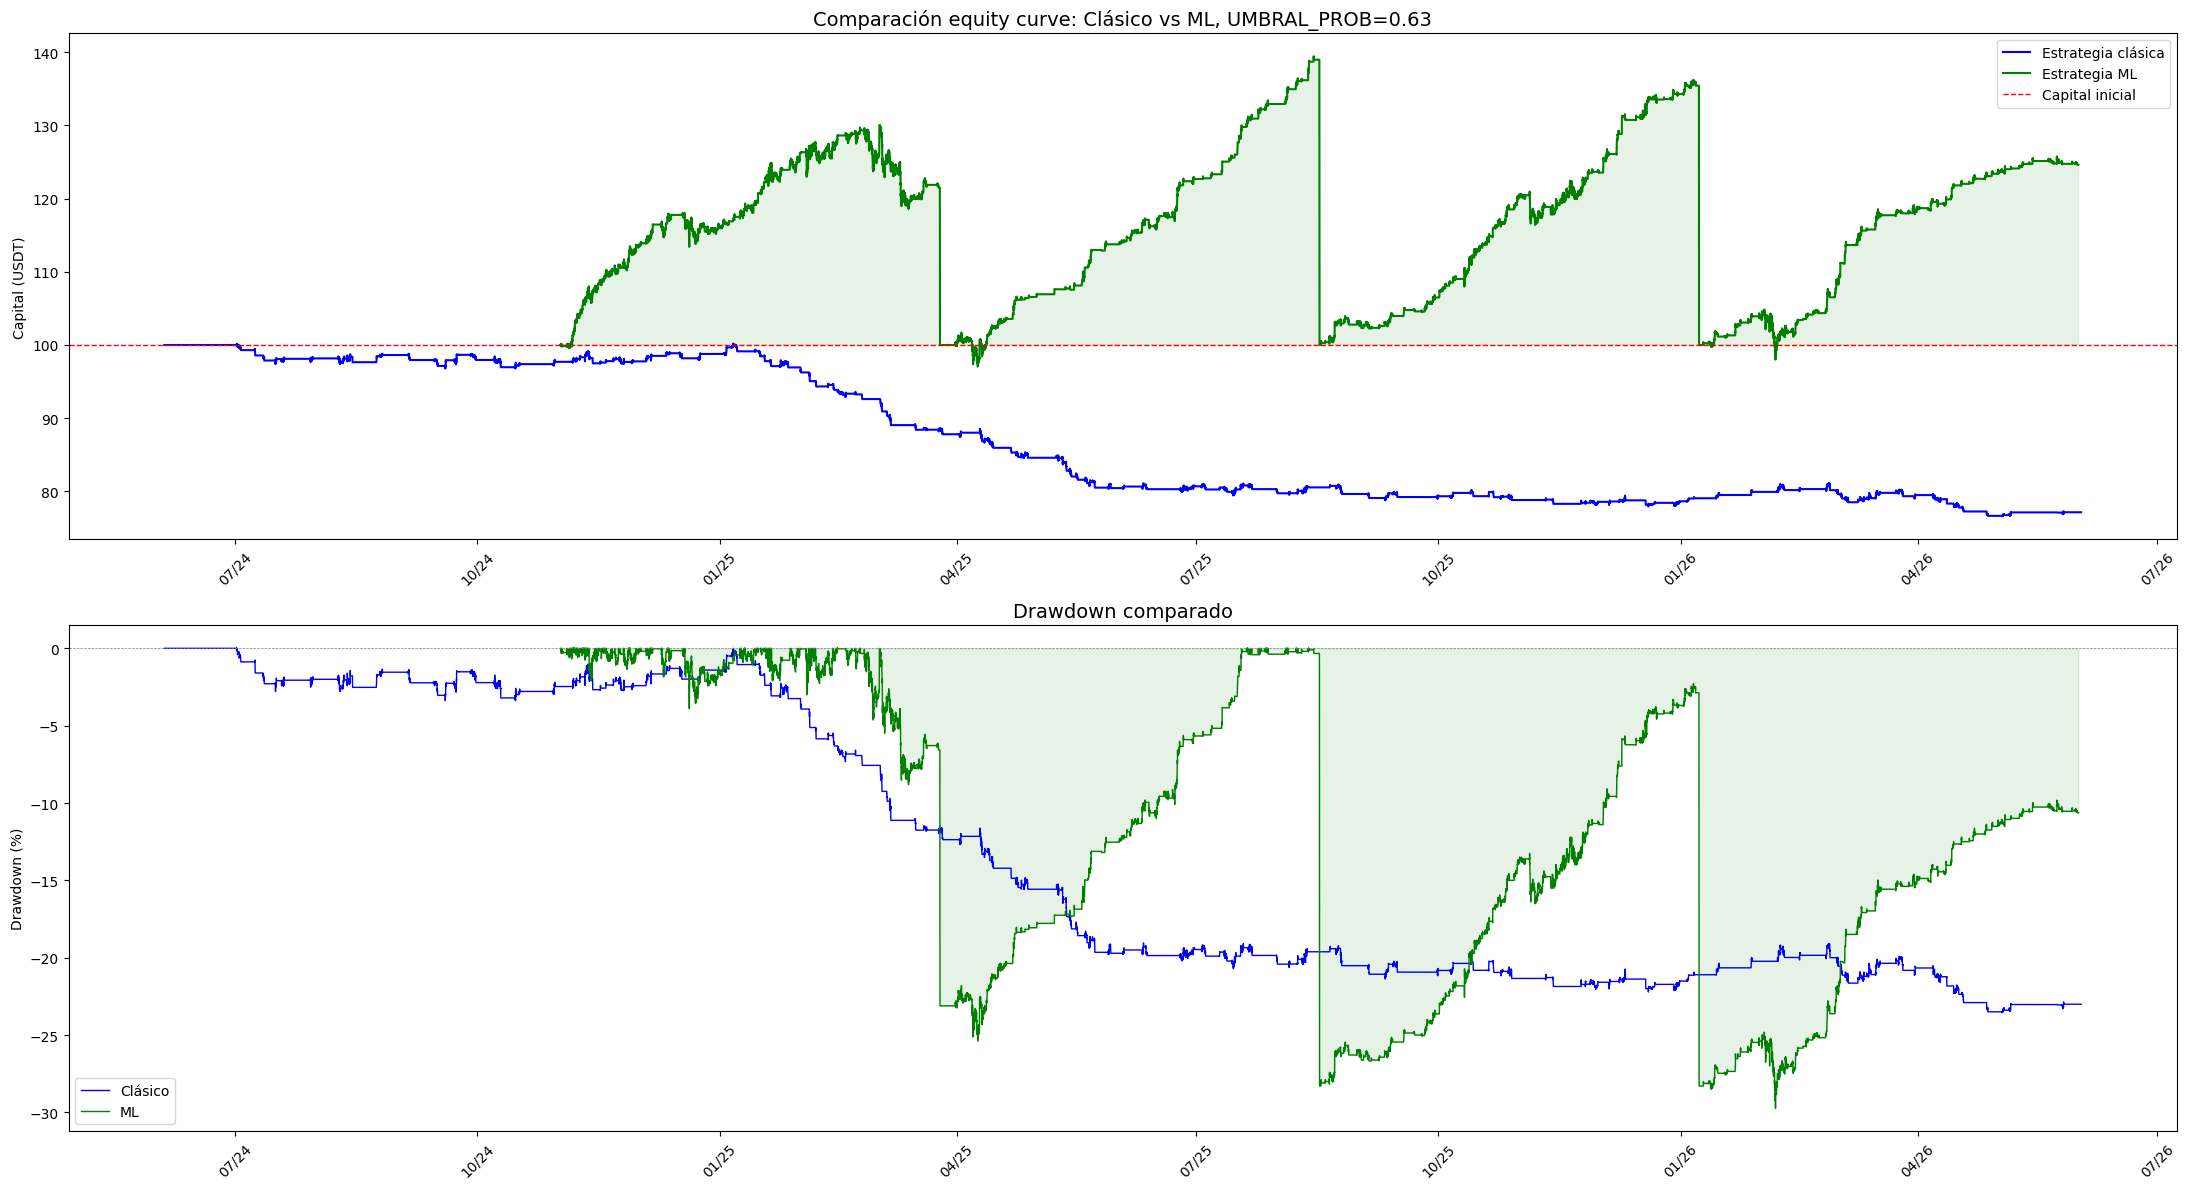

✅ Gráfico guardado como comparacion_clasico_vs_ml.png

  Drawdown por ventana (más realista para producción):
    V1 (11/2024): max drawdown -8.81%
    V2 (03/2025): max drawdown -4.58%
    V3 (08/2025): max drawdown -3.76%
    V4 (01/2026): max drawdown -6.54%


In [ ]:
# ============================================================
# EJECUCIÓN PRINCIPAL
# ============================================================
if __name__ == "__main__":
    print("📊 Backtesting comparativo: Clásico vs ML\n")

    # Cargamos datos
    print("Cargando datos...")
    df_15m = cargar_velas("ETHUSDT", "15m")
    df_15m['MM']  = ta.ema(df_15m['Close'], length=200)
    df_15m['RSI'] = ta.rsi(df_15m['Close'], length=14)
    adx = ta.adx(df_15m['High'], df_15m['Low'],
                 df_15m['Close'], length=14)
    df_15m['ADX'] = adx['ADX_14']
    sar = ta.psar(df_15m['High'], df_15m['Low'], df_15m['Close'])
    df_15m['SAR'] = sar['PSARl_0.02_0.2'].fillna(
                        sar['PSARs_0.02_0.2'])
    df_15m = df_15m.dropna()

    # Estrategia clásica
    print("Simulando estrategia clásica...")
    ops_c, equity_c, cap_c = simular_clasico(df_15m)

    # Features y dataset ML
    print("Construyendo features ML...")
    features_df, _ = construir_features("ETHUSDT")
    target = crear_target(df_15m.loc[features_df.index],
                          stop_loss=STOP_LOSS,
                          take_profit=TAKE_PROFIT,
                          max_velas=MAX_VELAS)
    features_df = features_df.join(target).dropna()

    # Estrategia ML con Walk Forward
    ops_ml, equity_ml, cap_ml = walk_forward_backtesting(
        features_df, df_15m)

    # Comparación de resultados
    print(f"\n{'='*50}")
    print("   RESULTADOS COMPARATIVOS - 2 AÑOS")
    print(f"{'='*50}")

    ret_c,  ops_c_n,  wr_c,  dd_c  = comparar(
        "Estrategia CLÁSICA",  ops_c,  equity_c,  cap_c)
    ret_ml, ops_ml_n, wr_ml, dd_ml = comparar(
        "Estrategia ML",       ops_ml, equity_ml, cap_ml)

    # Resumen final
    print(f"\n{'='*50}")
    print("   RESUMEN COMPARATIVO")
    print(f"{'='*50}")
    print(f"  {'Métrica':<22} {'Clásico':>10} {'ML':>10}")
    print(f"  {'─'*42}")
    print(f"  {'Retorno':<22} {ret_c:>9.2f}% {ret_ml:>9.2f}%")
    print(f"  {'Operaciones':<22} {ops_c_n:>10} {ops_ml_n:>10}")
    print(f"  {'Win Rate':<22} {wr_c:>9.1f}% {wr_ml:>9.1f}%")
    print(f"  {'Max Drawdown':<22} {dd_c:>9.2f}% {dd_ml:>9.2f}%")
    print(f"{'='*50}")

    ganador = "ML" if ret_ml > ret_c else "Clásico"
    print(f"\n  Estrategia ganadora: {ganador}")

    # Gráfico
    graficar_comparacion(equity_c, equity_ml, ops_c, ops_ml)

    # Al final de backtesting_ml.py, agregá esto:
    print("\n  Drawdown por ventana (más realista para producción):")
    n          = len(features_df)
    tam_test   = n // 5

    for i in range(4):
        fin_train = tam_test * (i + 1)
        fin_test  = tam_test * (i + 2)
        f_test    = features_df.iloc[fin_train:fin_test]

        # Filtramos equity de esa ventana
        t_ini = f_test.index[0]
        t_fin = f_test.index[-1]
        eq_v  = equity_ml[
            (equity_ml['time'] >= t_ini) &
            (equity_ml['time'] <= t_fin)
        ]['equity'].values

        if len(eq_v) > 0:
            peak = np.maximum.accumulate(eq_v)
            dd   = (eq_v - peak) / peak * 100
            fecha = t_ini.strftime('%m/%Y')
            print(f"    V{i+1} ({fecha}): max drawdown {dd.min():.2f}%")